# Image Classification with Transfer Learning

## Overview

This project demonstrates image classification using **transfer learning** with a pretrained **ResNet18** convolutional neural network.

A pretrained ResNet18 model was adapted to classify images from the **CIFAR-10** dataset. The original classification layer was replaced with a new layer containing 10 output classes, while the pretrained layers were frozen during training.

The project covers the complete workflow from dataset preparation and preprocessing to model training, evaluation, class-wise accuracy analysis, and confusion matrix visualization.

### Objective

The objective is to demonstrate how a pretrained deep learning model can be adapted to a new image classification task using transfer learning.

## Dataset

This project uses the **CIFAR-10** dataset, which contains 60,000 color images across 10 classes.

The original dataset consists of:

- **50,000** training images
- **10,000** test images
- **10 classes**
- Image size: **32 × 32 pixels**

The classes are:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

For this experiment, a subset of **5,000 training images** and **1,000 test images** was used to keep training practical on CPU resources.

## Transfer Learning Approach

This project uses **ResNet18**, a convolutional neural network pretrained on the ImageNet dataset.

Instead of training the entire network from scratch:

1. The pretrained ResNet18 model was loaded.
2. The pretrained layers were frozen.
3. The original final classification layer was replaced with a new fully connected layer containing 10 output classes.
4. Only the new classification layer was trained on the CIFAR-10 subset.
5. The trained model was evaluated on the test subset.

This approach allows a pretrained visual representation to be adapted to a new classification task with relatively limited training resources.

## Workflow

The project follows this pipeline:

**CIFAR-10 Dataset**  
↓  
**Image Preprocessing & Normalization**  
↓  
**Pretrained ResNet18**  
↓  
**Freeze Pretrained Layers**  
↓  
**Replace Final Classification Layer**  
↓  
**Train on CIFAR-10 Subset**  
↓  
**Evaluate on Test Subset**  
↓  
**Class-wise Accuracy & Confusion Matrix**

## Technologies Used

- **Python**
- **PyTorch**
- **Torchvision**
- **ResNet18**
- **CIFAR-10**
- **NumPy**
- **Matplotlib**
- **Scikit-learn**
- **Google Colab**

## Evaluation

The model was evaluated using the following methods:

- Overall test accuracy
- Class-wise accuracy for all 10 CIFAR-10 classes
- Confusion matrix to visualize classification performance across classes
- Sample predictions comparing predicted and actual labels

These evaluations provide a more detailed view of model performance beyond overall accuracy.

## Conclusion

This project demonstrates the practical use of transfer learning for image classification. A pretrained ResNet18 model was adapted to the CIFAR-10 dataset by replacing its final classification layer and training it on a subset of the dataset.

The experiment achieved **72.48% test accuracy** after one training epoch using 5,000 training images and 1,000 test images.

The project also demonstrates model evaluation through class-wise accuracy, sample predictions, and a confusion matrix.

In [1]:
!pip install -q torch torchvision

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Using CPU.")

Device: cpu
GPU not available. Using CPU.


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)

 26%|██▌       | 44.3M/170M [05:12<14:49, 142kB/s]


KeyboardInterrupt: 

In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print("Pretrained ResNet18 loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


Pretrained ResNet18 loaded successfully!


In [7]:
for param in model.parameters():
    param.requires_grad = False

print("Pretrained layers frozen.")

Pretrained layers frozen.


In [8]:
num_classes = 10

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print("Classification layer updated for CIFAR-10.")

Classification layer updated for CIFAR-10.


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function and optimizer configured.")

Loss function and optimizer configured.


In [10]:
model.train()

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

print("Training completed successfully!")

NameError: name 'train_loader' is not defined

In [11]:
from torch.utils.data import Subset

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("Training samples:", len(train_subset))
print("Test samples:", len(test_subset))

RuntimeError: Dataset not found or corrupted. You can use download=True to download it

In [12]:
from torch.utils.data import Subset

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("Training samples:", len(train_subset))
print("Test samples:", len(test_subset))

RuntimeError: Dataset not found or corrupted. You can use download=True to download it

In [13]:
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 170M/170M [23:44<00:00, 120kB/s]


Training images: 50000
Test images: 10000


In [14]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

print("Training samples:", len(train_subset))
print("Test samples:", len(test_subset))

Training samples: 5000
Test samples: 1000


In [15]:
transfer_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transfer_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transfer_transform
)

train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("Transfer-learning data loaders ready!")

Transfer-learning data loaders ready!


In [23]:
model.train()

total_loss = 0.0

for batch_idx, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

epoch_loss = total_loss / len(train_loader)

print(f"Epoch training loss: {epoch_loss:.4f}")
print("Training completed successfully!")

Epoch training loss: 0.9142
Training completed successfully!


In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 65.60%


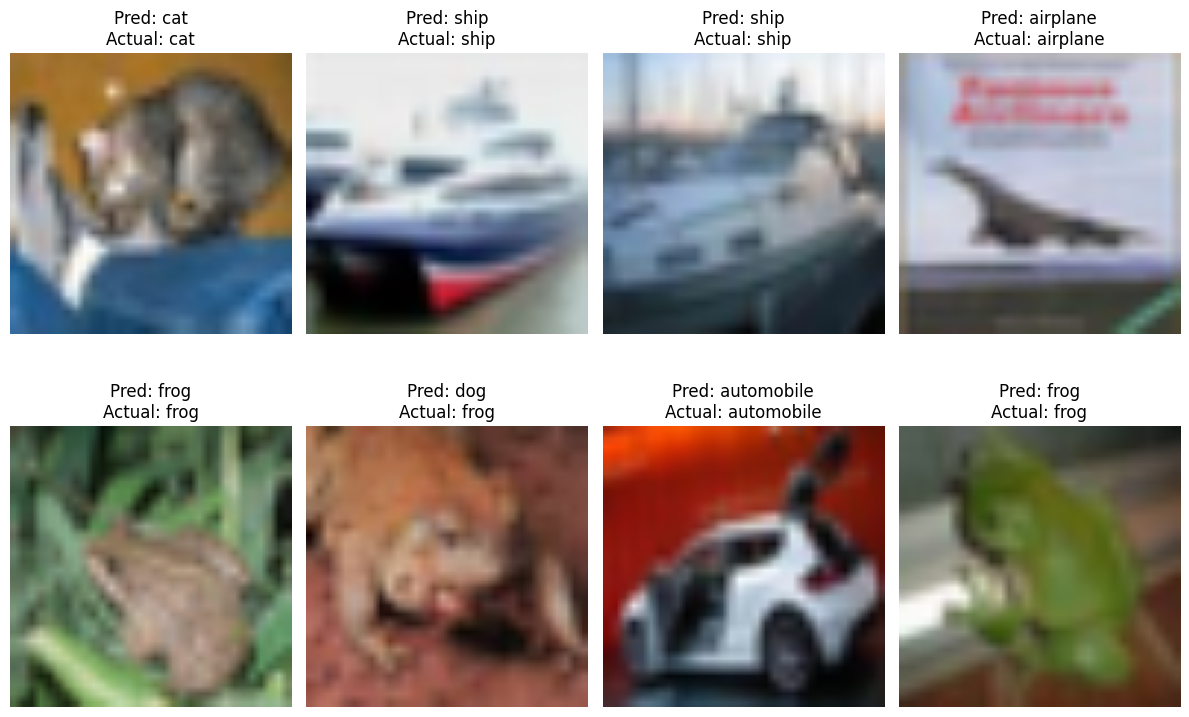

In [18]:
class_names = train_dataset.classes

images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    outputs = model(images.to(device))
    predictions = torch.argmax(outputs, dim=1).cpu()

plt.figure(figsize=(12, 8))

for i in range(8):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for display
    image = image * np.array([0.229, 0.224, 0.225]) + np.array(
        [0.485, 0.456, 0.406]
    )
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")

    predicted_class = class_names[predictions[i]]
    actual_class = class_names[labels[i]]

    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}"
    )

plt.tight_layout()
plt.show()

In [19]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, prediction in zip(labels, predicted):
            class_total[label.item()] += 1
            if label == prediction:
                class_correct[label.item()] += 1

print("Class-wise accuracy:")

for i in range(10):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f"{class_names[i]:12s}: {accuracy:.2f}%")

Class-wise accuracy:
airplane    : 52.43%
automobile  : 69.66%
bird        : 50.00%
cat         : 63.11%
deer        : 74.44%
dog         : 56.98%
frog        : 72.32%
horse       : 54.90%
ship        : 87.74%
truck       : 72.48%


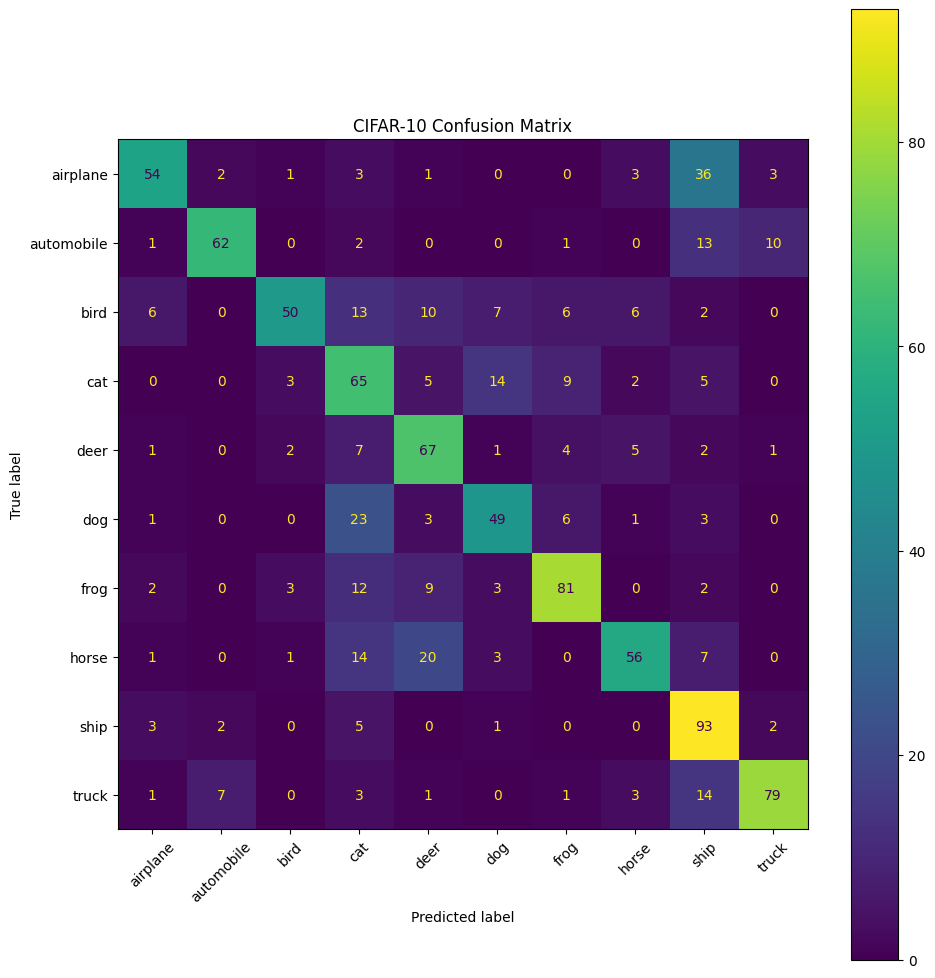

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1).cpu()

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.numpy())

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
print("Final recorded training loss: 1.0764")
print("Test accuracy: 65.60%")

Final recorded training loss: 1.0764
Test accuracy: 65.60%


In [24]:
results = {
    "Training samples": len(train_subset),
    "Test samples": len(test_subset),
    "Model": "ResNet18",
    "Training approach": "Transfer Learning",
    "Epochs": 1,
    "Final training loss": epoch_loss,
    "Test accuracy": accuracy
}

print("Project Results")
print("-" * 30)

for key, value in results.items():
    print(f"{key}: {value}")

Project Results
------------------------------
Training samples: 5000
Test samples: 1000
Model: ResNet18
Training approach: Transfer Learning
Epochs: 1
Final training loss: 0.9142087026006857
Test accuracy: 72.4770642201835


## Results Summary

The transfer learning model achieved a test accuracy of **72.48%** on a 1,000-image CIFAR-10 test subset after one training epoch.

| Metric | Result |
|---|---:|
| Training samples | 5,000 |
| Test samples | 1,000 |
| Model | ResNet18 |
| Training approach | Transfer Learning |
| Epochs | 1 |
| Training loss | 0.9142 |
| Test accuracy | 72.48% |

The results demonstrate that a pretrained ResNet18 model can be adapted to CIFAR-10 image classification by replacing and training its final classification layer.

## Limitations & Future Improvements

This project uses a relatively small subset of CIFAR-10 and trains only the final classification layer of a pretrained ResNet18 model for one epoch. The experiment was also performed using CPU resources.

Possible improvements include:

- Training on the complete CIFAR-10 training dataset.
- Fine-tuning additional ResNet18 layers.
- Training for multiple epochs.
- Applying data augmentation.
- Comparing ResNet18 with other pretrained architectures.
- Evaluating additional metrics such as precision, recall, and F1-score.